# Method Comparison KDE Analysis (CertCF vs NN vs GS)

This notebook compares proximity distributions across methods on the same benchmark run,
with per-dataset KDE plots for `L1` and `L2` distances.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks.utils import (
    annotate_common_success_subset,
    attach_tabular_manifoldness_metrics,
    load_result,
    load_tabular_manifold_resources,
    matched_success_summary,
    method_comparison_summary,
    plot_conditioned_proximity_kdes,
    plot_proximity_kdes_by_dataset,
    prepare_benchmark_df,
    setup_notebook_style,
    summarize_manifoldness,
)

setup_notebook_style()

CONFIG = "benchmark_full_all_200q_alpha0.99"
RESULT_FILENAME = f"{CONFIG}.parquet"
CONFIG_PATH = ROOT / f"configs/benchmarks/{CONFIG}.yaml"
_candidates = [
    Path("results") / RESULT_FILENAME,
    Path("..") / "results" / RESULT_FILENAME,
]
RESULT_PATH = next((p.resolve() for p in _candidates if p.exists()), None)
if RESULT_PATH is None:
    looked = '\n'.join(str(p.resolve()) for p in _candidates)
    raise FileNotFoundError(f"Missing result file. Looked in:\n{looked}")

DATASET_ORDER = ["adult", "compas", "german_credit", "give_me_some_credit", "heloc", "lending_club", "wisconsin_breast_cancer"]
METHOD_ORDER = ["certcf_top3", "nn", "gs"]
METHOD_LABELS = {
    "certcf_top3": "CertCF (boundary-random, top-3)",
    "nn": "Nearest Neighbor",
    "gs": "Growing Spheres",
    "dice": "DiCE",
}
PALETTE = {
    "certcf_top3": "#1f77b4",
    "nn": "#ff7f0e",
    "gs": "#2ca02c",
    "dice": "#d62728",
}


def _method_label_fn(frame: pd.DataFrame) -> pd.Series:
    qk = pd.to_numeric(frame.get("meta__query_k_candidates", np.nan), errors="coerce")
    labels = frame["run_name"].astype(str).copy()
    certcf_mask = labels.str.startswith("certcf") & qk.notna()
    labels.loc[certcf_mask] = qk.loc[certcf_mask].astype(int).map(lambda value: f"certcf_top{value}")
    return labels


## Load And Prepare Results

In [2]:
df = load_result(RESULT_PATH, method_label_fn=_method_label_fn)

comparison_df = prepare_benchmark_df(
    df,
    methods=METHOD_ORDER,
    dataset_order=DATASET_ORDER,
    method_order=METHOD_ORDER,
)
plot_df = prepare_benchmark_df(
    df,
    methods=METHOD_ORDER,
    dataset_order=DATASET_ORDER,
    method_order=METHOD_ORDER,
    success_only_rows=True,
)


## KDE Distribution Comparison By Dataset

The first plots compare method-wise distributions of proximity (`L1`, `L2`) for each dataset.

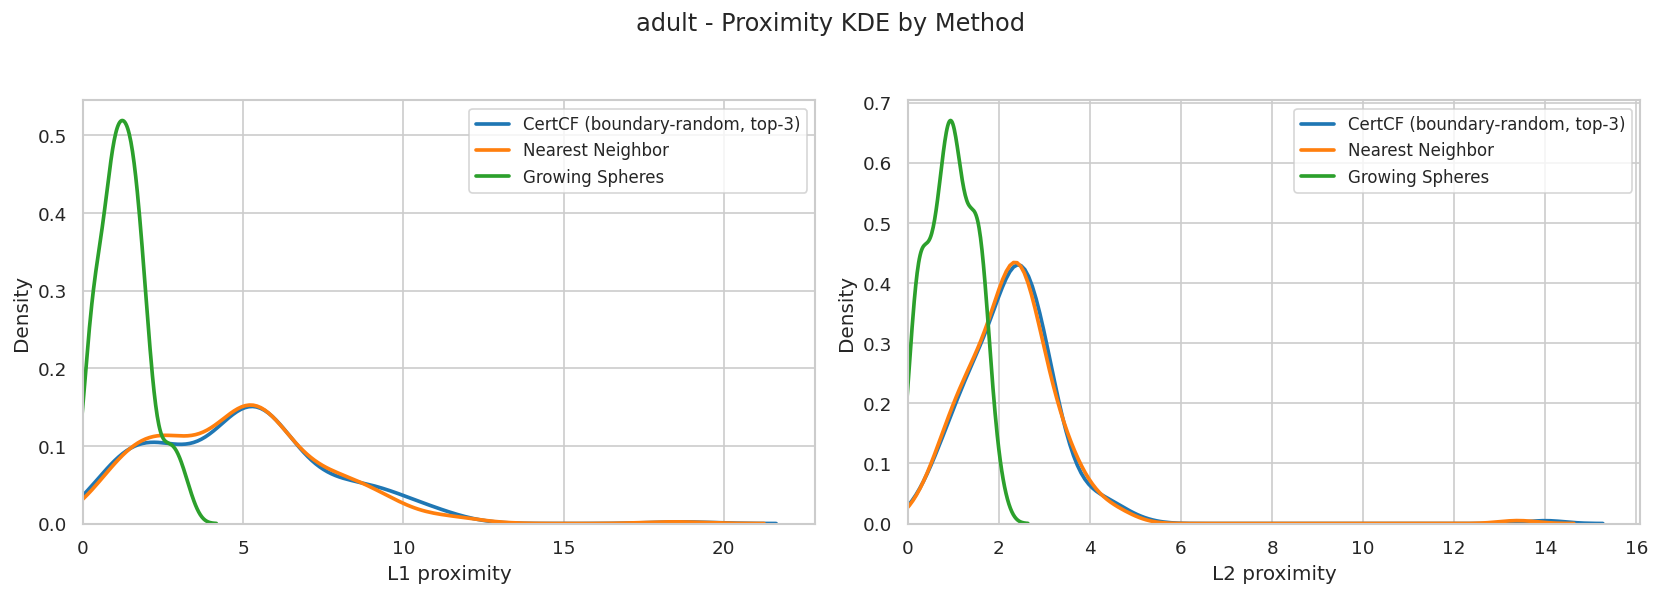

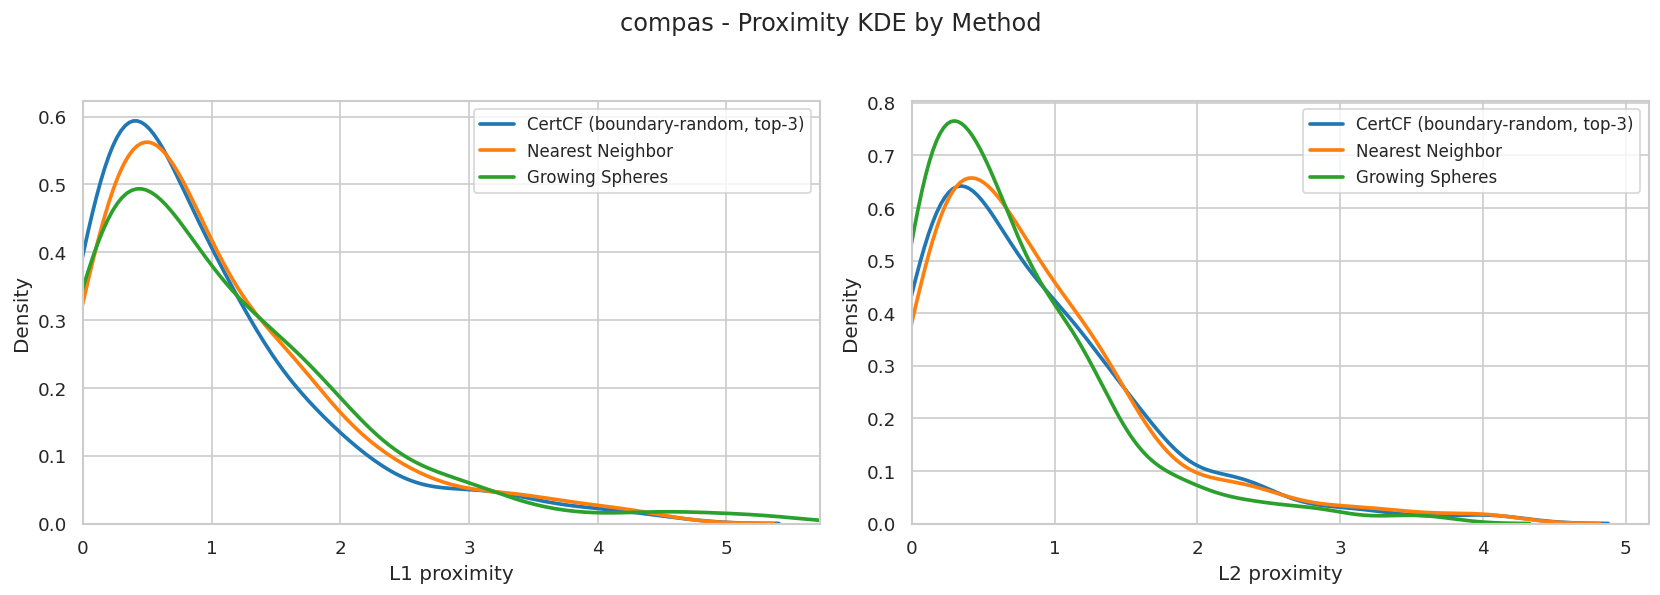

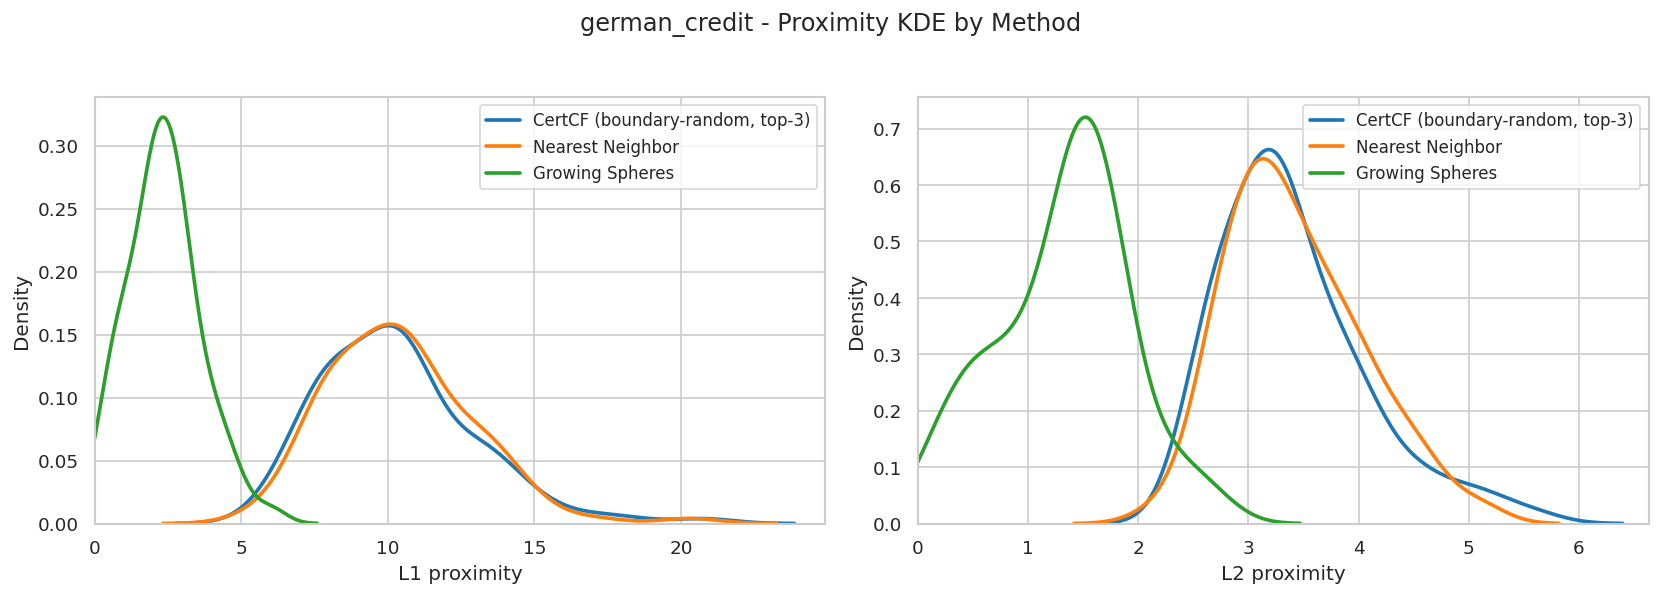

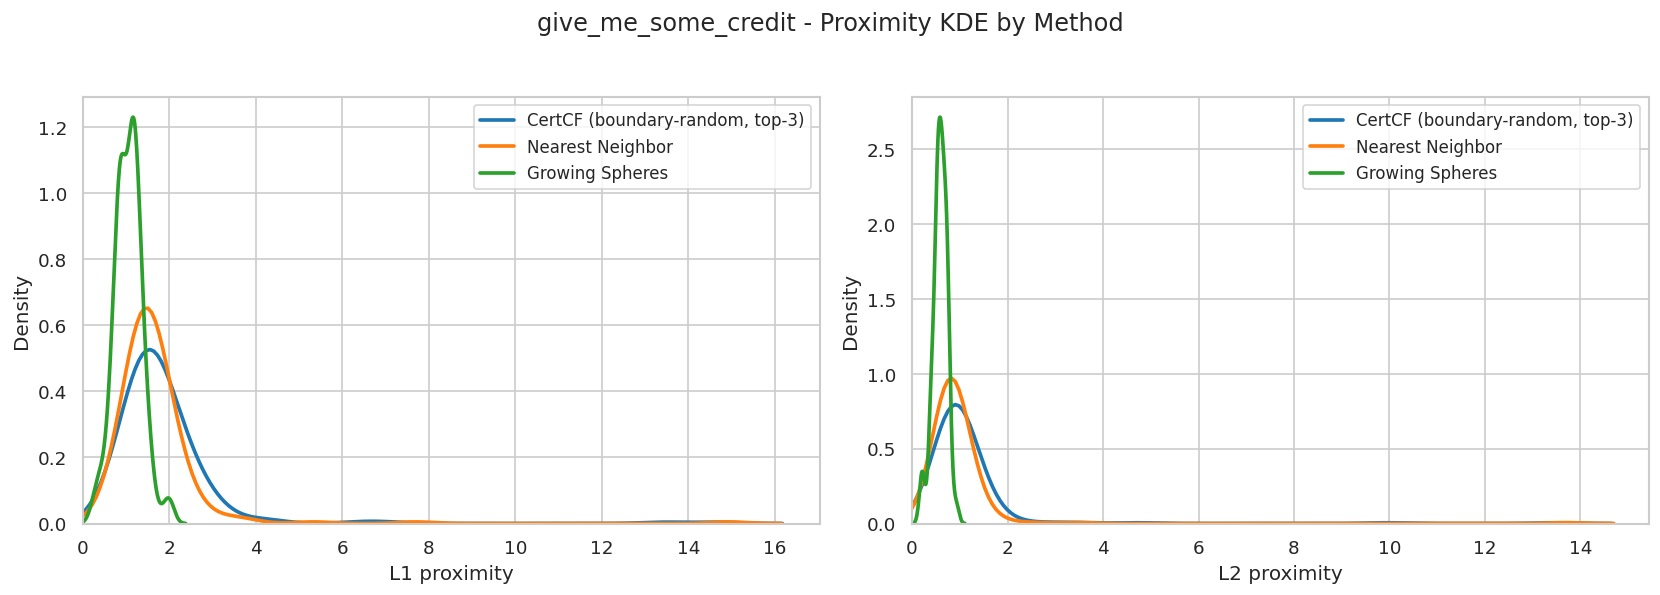

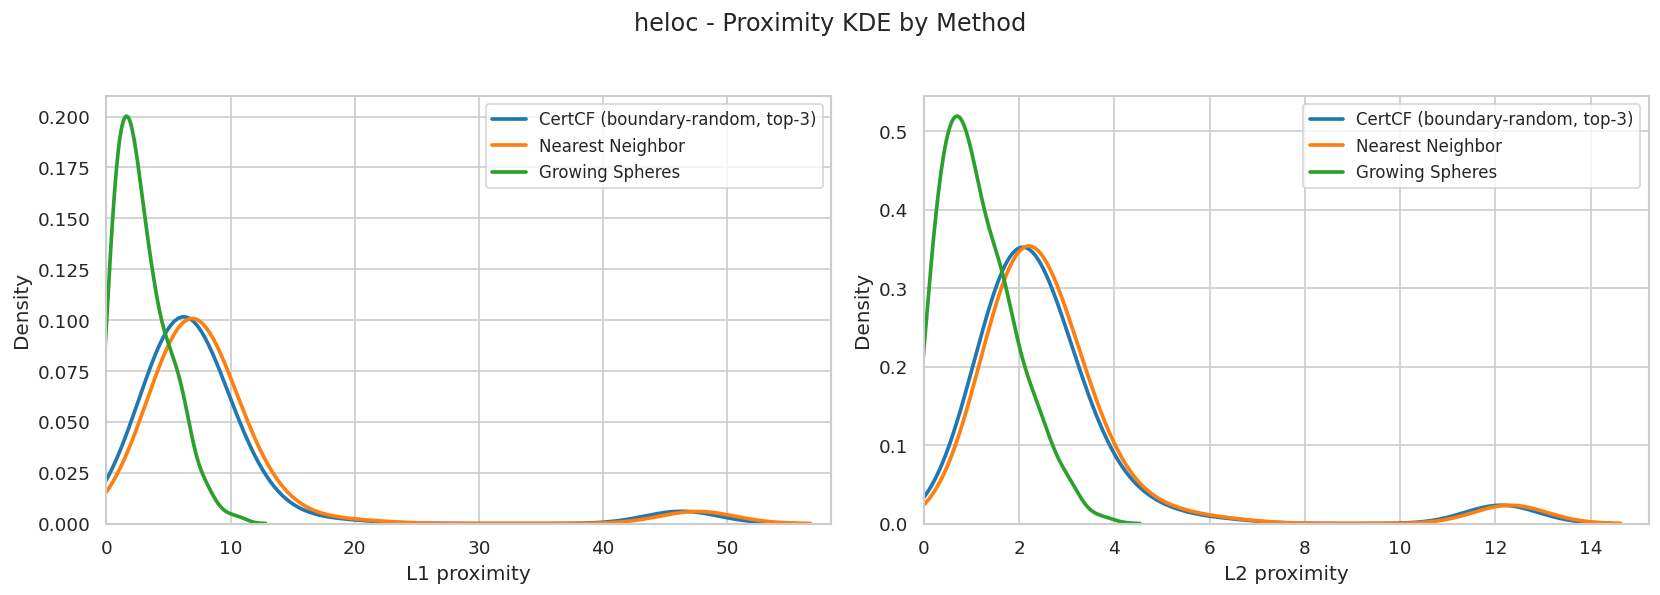

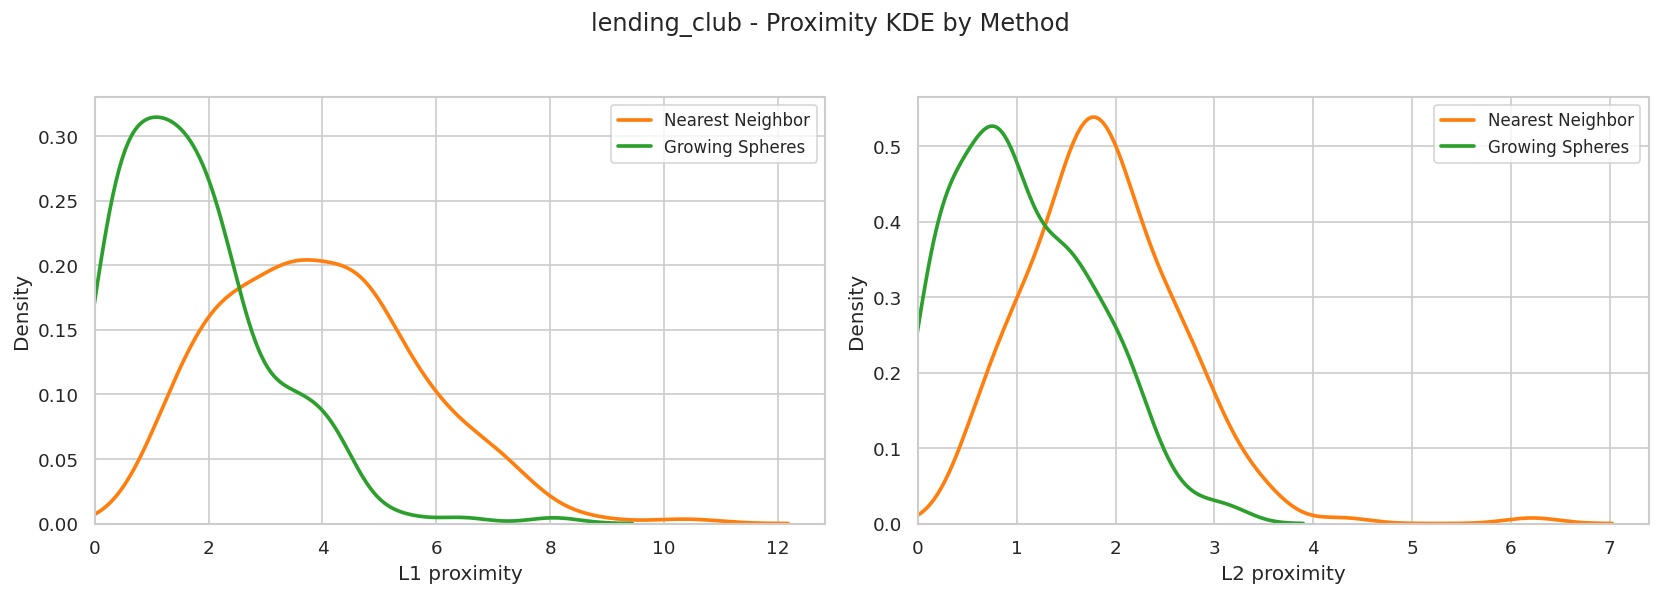

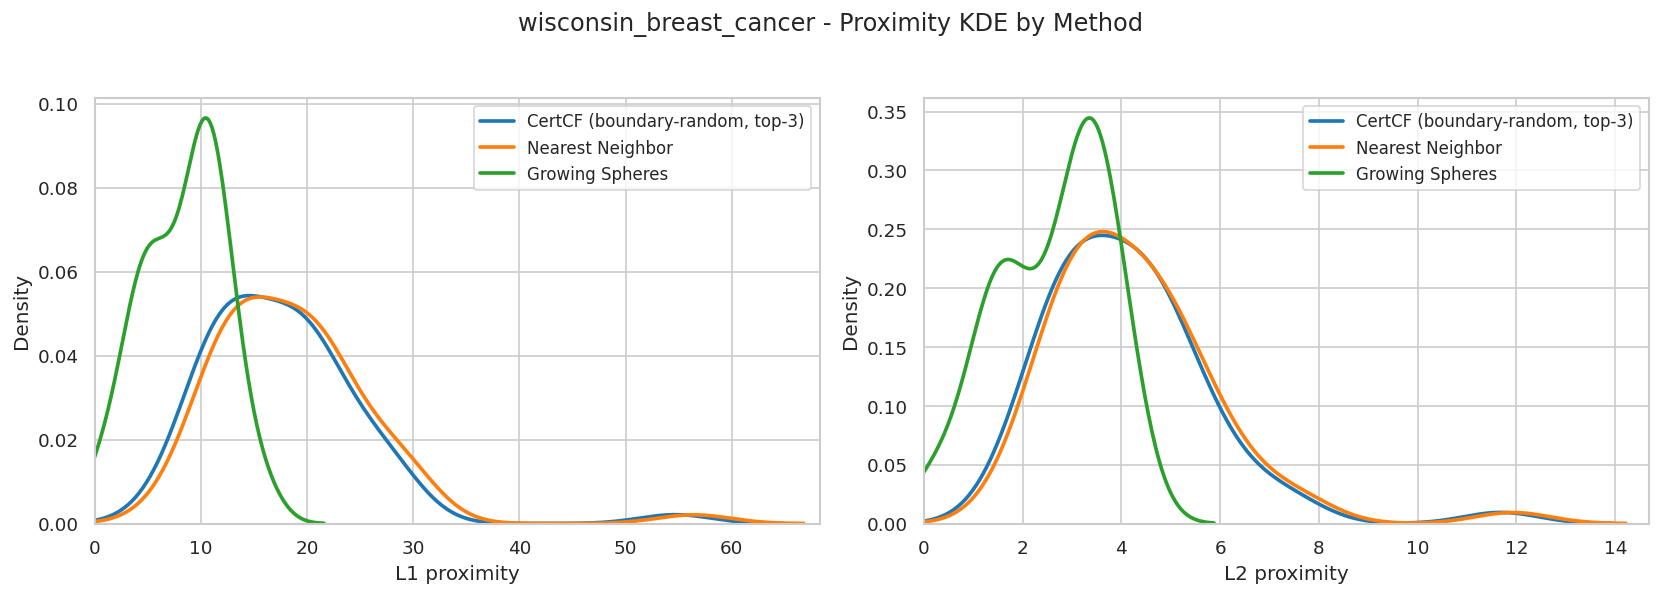

In [3]:
figures = plot_proximity_kdes_by_dataset(
    plot_df,
    dataset_order=DATASET_ORDER,
    method_order=METHOD_ORDER,
    palette=PALETTE,
    method_labels=METHOD_LABELS,
)
for _, fig, _ in figures:
    plt.show()


## Proximity Result Table

This table summarizes proximity with both mean and median, alongside validity and runtime.

In [4]:
proximity_summary = method_comparison_summary(
    comparison_df,
    order=METHOD_ORDER,
)
display(proximity_summary.round(3))


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/utils/summaries.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby([dataset_col, method_col], dropna=False, sort=False)


,dataset,method_label,n,valid_pct,l1_mean,l1_median,l2_mean,l2_median,runtime_mean_s,runtime_median_s
0,adult,certcf_top3,200,100.000,4.939,5.002,2.306,2.297,0.570,0.022
1,adult,nn,200,100.000,4.850,4.954,2.284,2.266,0.001,0.001
2,adult,gs,200,81.500,1.291,1.226,0.956,0.945,0.022,0.024
3,compas,certcf_top3,200,100.000,0.948,0.641,0.854,0.624,0.054,0.011
4,compas,nn,200,100.000,1.053,0.788,0.882,0.647,0.000,0.000
5,compas,gs,200,100.000,1.094,0.818,0.702,0.528,0.002,0.002
6,german_credit,certcf_top3,100,100.000,10.317,10.073,3.405,3.253,0.447,0.062
7,german_credit,nn,100,100.000,10.406,10.173,3.428,3.301,0.000,0.000
8,german_credit,gs,100,62.000,2.357,2.238,1.322,1.414,0.018,0.019
9,give_me_some_credit,certcf_top3,200,100.000,1.876,1.612,1.105,0.908,0.013,0.012


## Proximity Table On Common Successful Queries

This table restricts the analysis to the intersection of query points for which **all methods** succeeded within each dataset.

In [5]:
common_counts_df, matched_summary = matched_success_summary(
    comparison_df,
    order=METHOD_ORDER,
)
display(common_counts_df)
display(matched_summary.round(3))


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/utils/summaries.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_groups = df.groupby(dataset_col, dropna=False, sort=False)
/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/utils/summaries.py:174: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  dataset_df.pivot_table(
/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/utils/summaries.py:196: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

,dataset,n_common_queries
0,adult,163
1,compas,200
2,german_credit,62
3,give_me_some_credit,200
4,heloc,191
5,lending_club,0
6,wisconsin_breast_cancer,41


,dataset,method_label,n_common_queries,l1_mean,l1_median,l2_mean,l2_median,runtime_mean_s,runtime_median_s
0,adult,certcf_top3,163,4.250,4.481,2.025,2.095,0.542,0.022
1,adult,nn,163,4.167,4.466,2.022,2.136,0.001,0.001
2,adult,gs,163,1.291,1.226,0.956,0.945,0.022,0.022
3,compas,certcf_top3,200,0.948,0.641,0.854,0.624,0.054,0.011
4,compas,nn,200,1.053,0.788,0.882,0.647,0.000,0.000
5,compas,gs,200,1.094,0.818,0.702,0.528,0.002,0.002
6,german_credit,certcf_top3,62,9.330,9.039,3.237,3.175,0.412,0.024
7,german_credit,nn,62,9.568,9.320,3.269,3.156,0.000,0.000
8,german_credit,gs,62,2.357,2.238,1.322,1.414,0.017,0.018
9,give_me_some_credit,certcf_top3,200,1.876,1.612,1.105,0.908,0.013,0.012


## KDE Conditioned On Common-Success Membership

For each dataset and method, these plots compare the proximity distribution on successful queries that belong to the common-success intersection against the successful queries outside that intersection.

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/utils/filters.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([*by, method_col])["success"]
/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/utils/filters.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


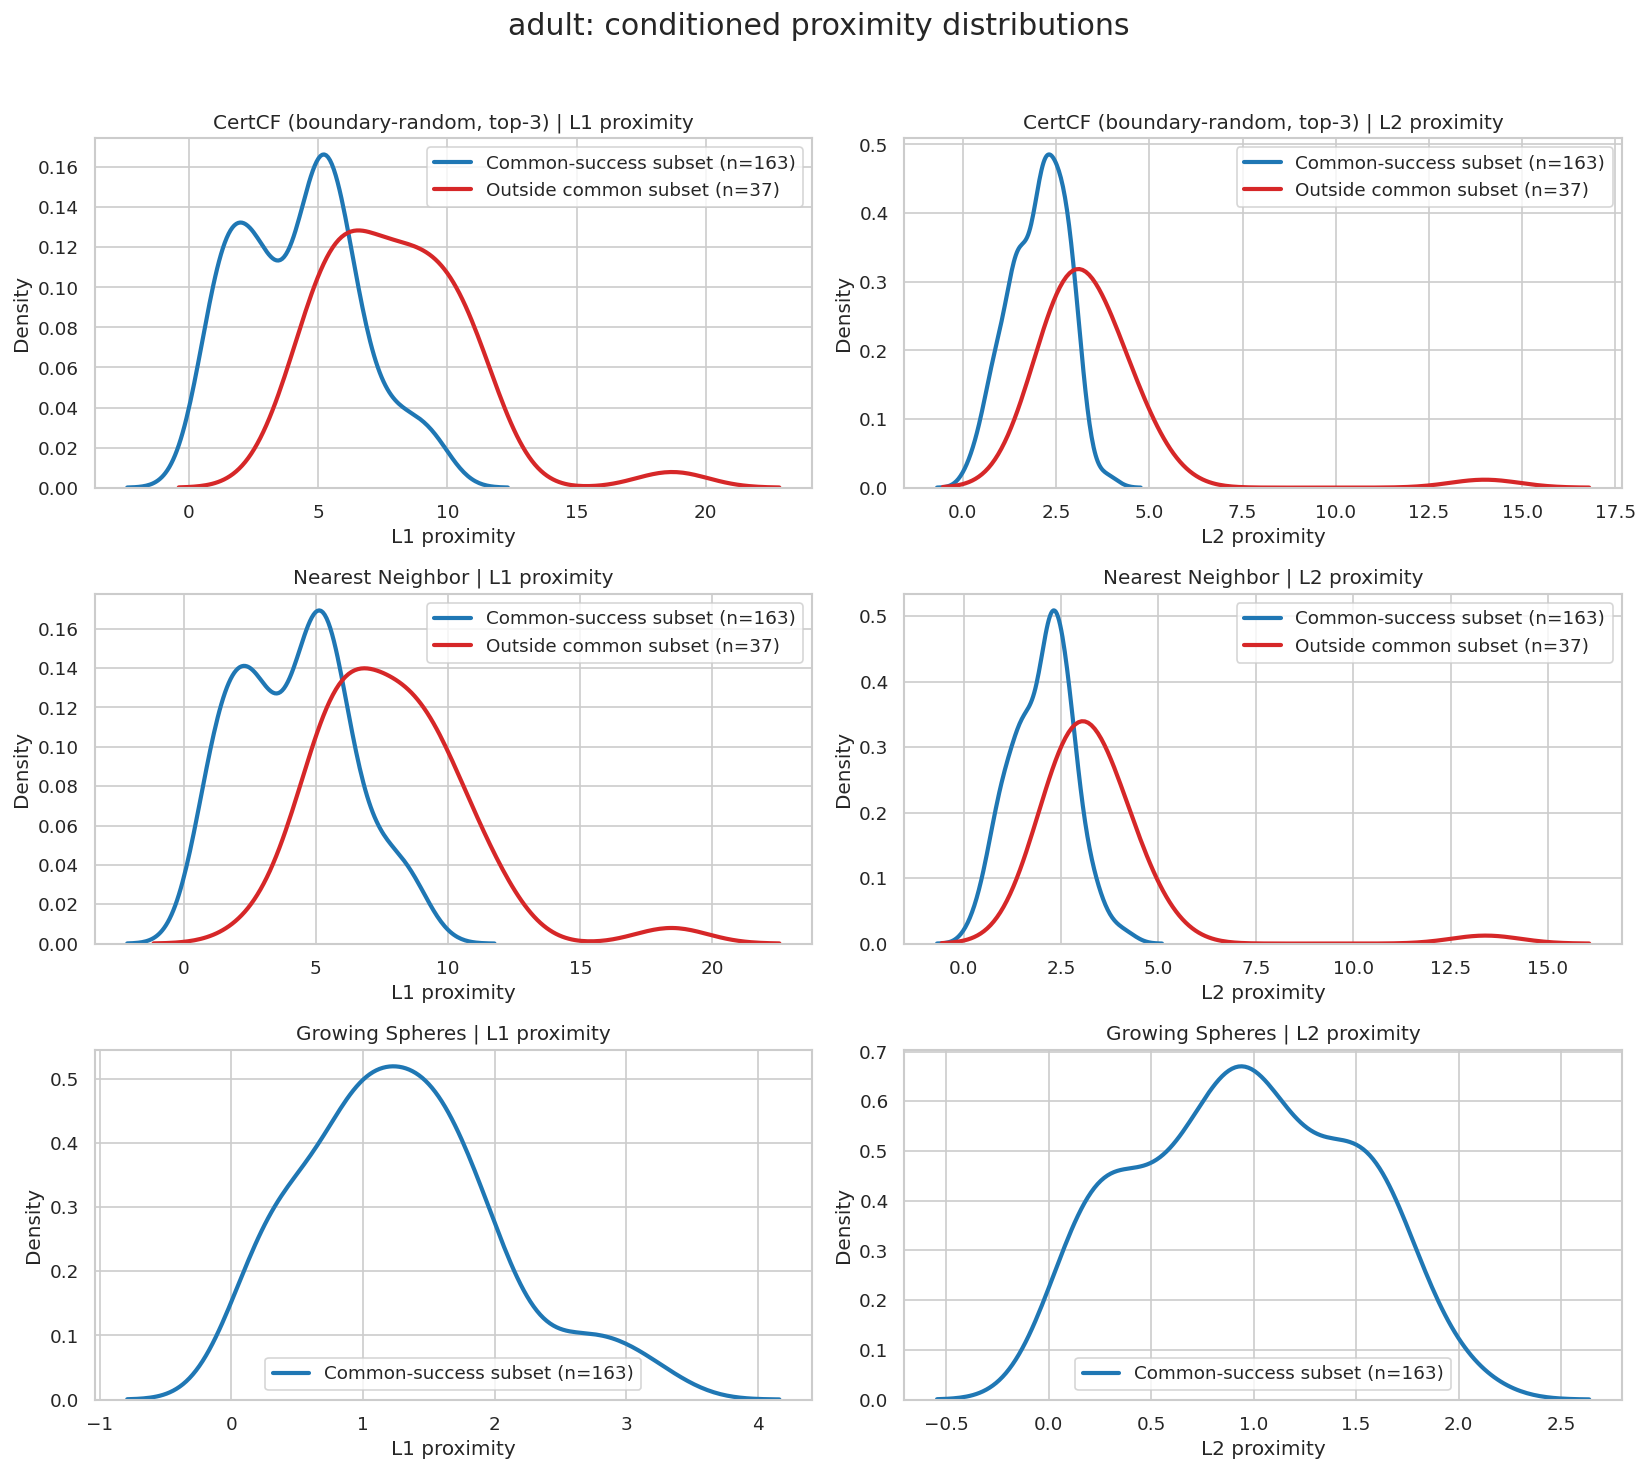

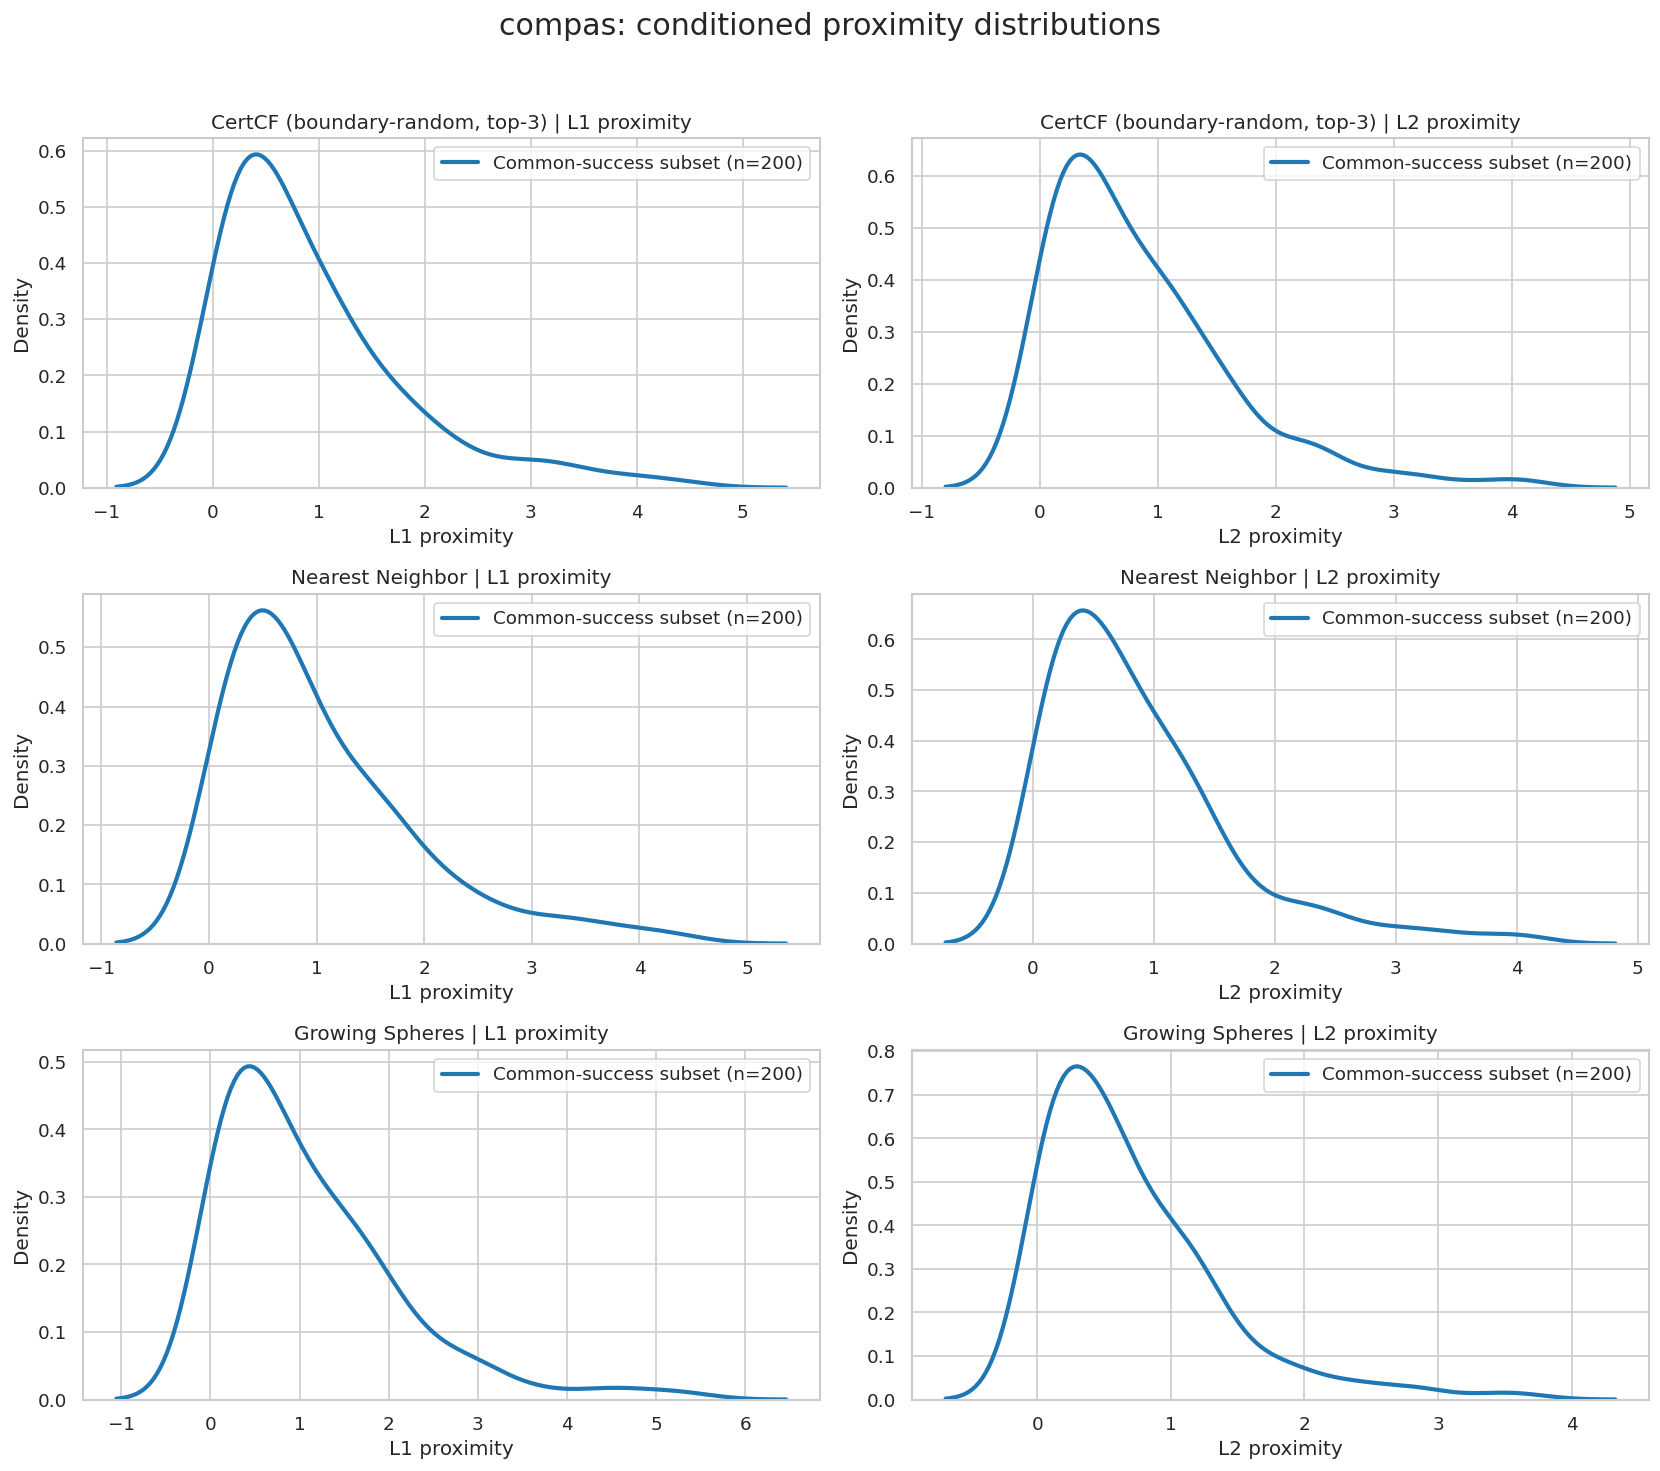

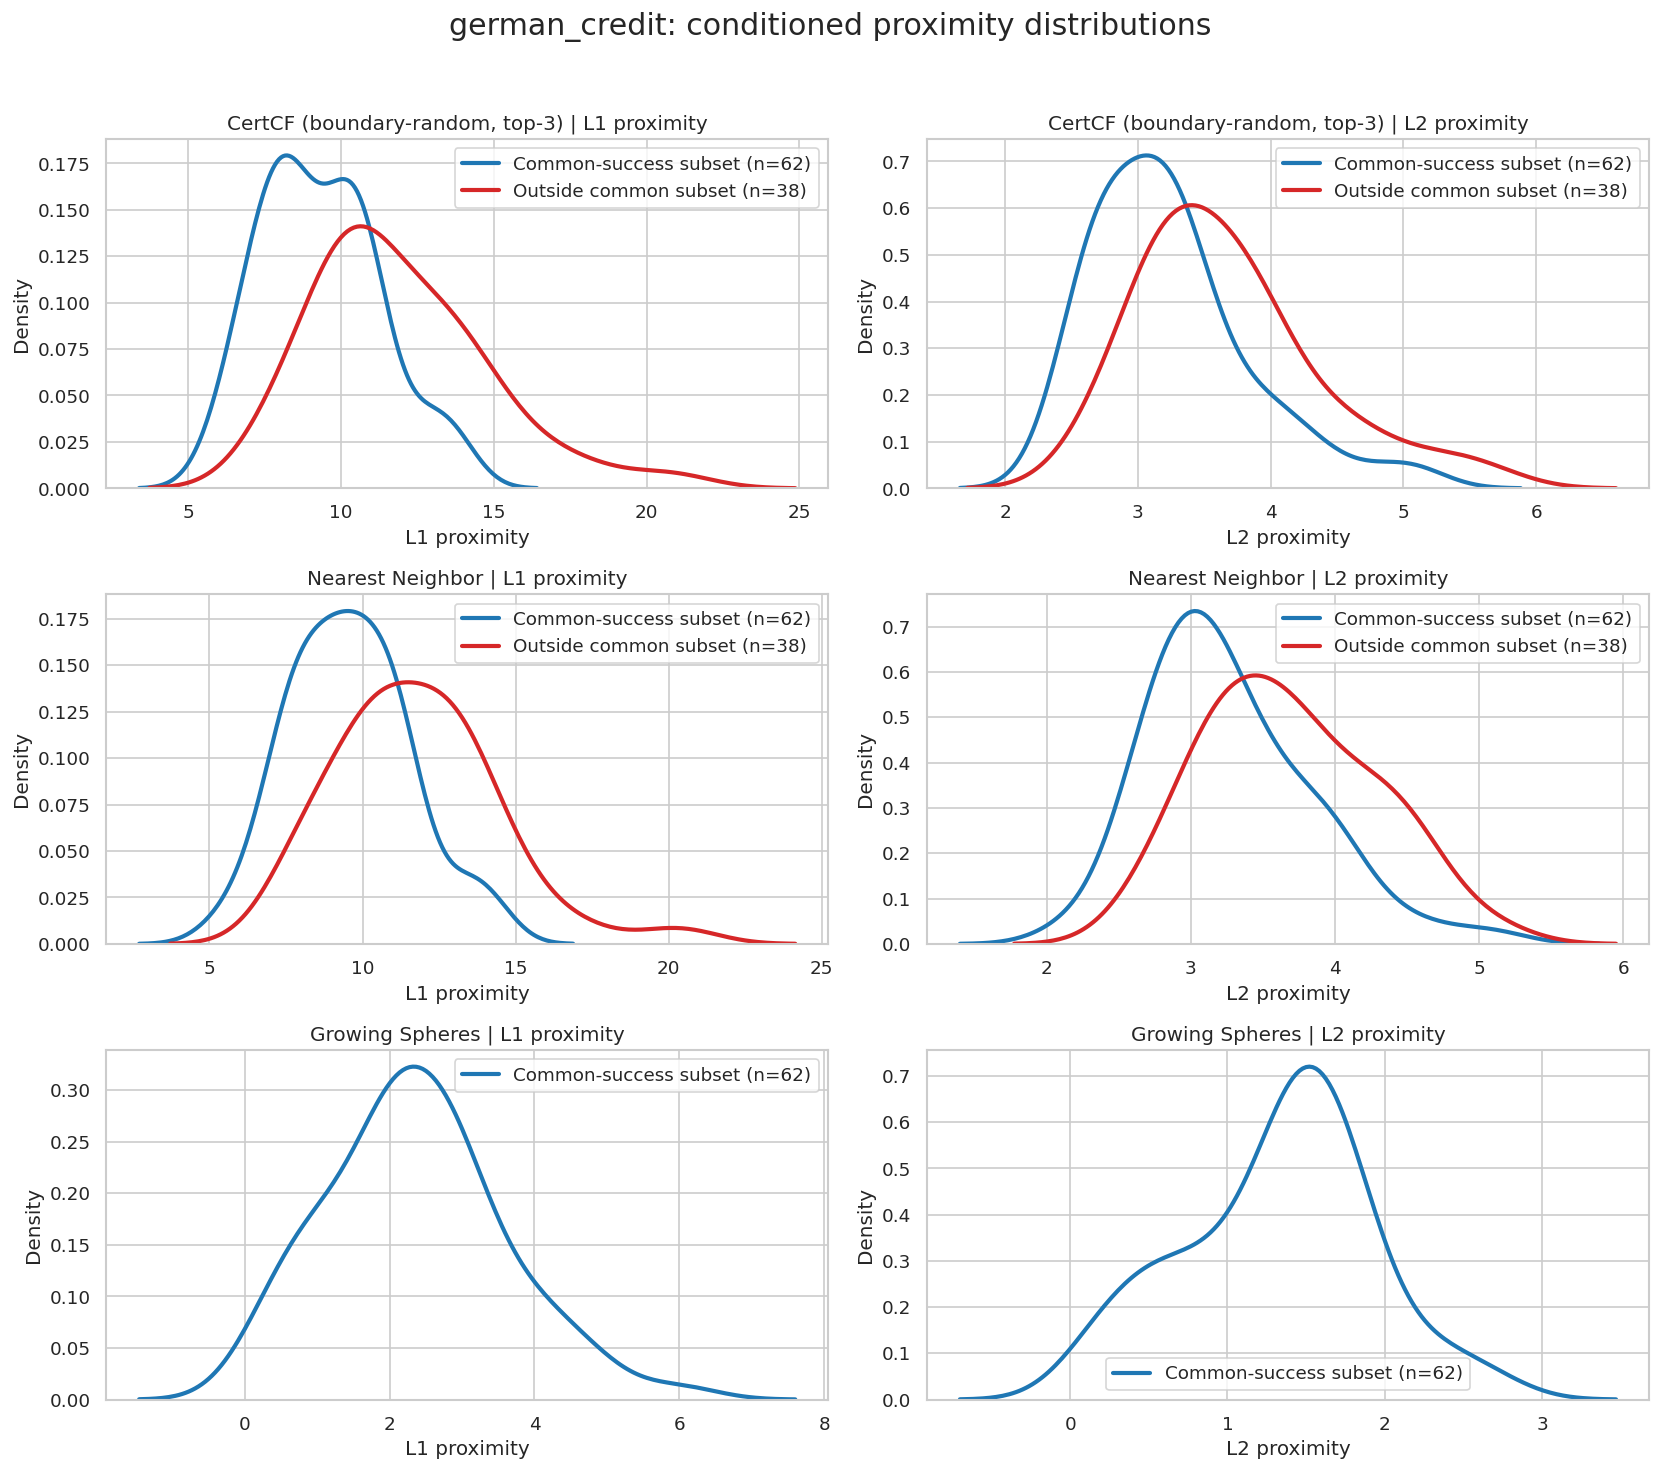

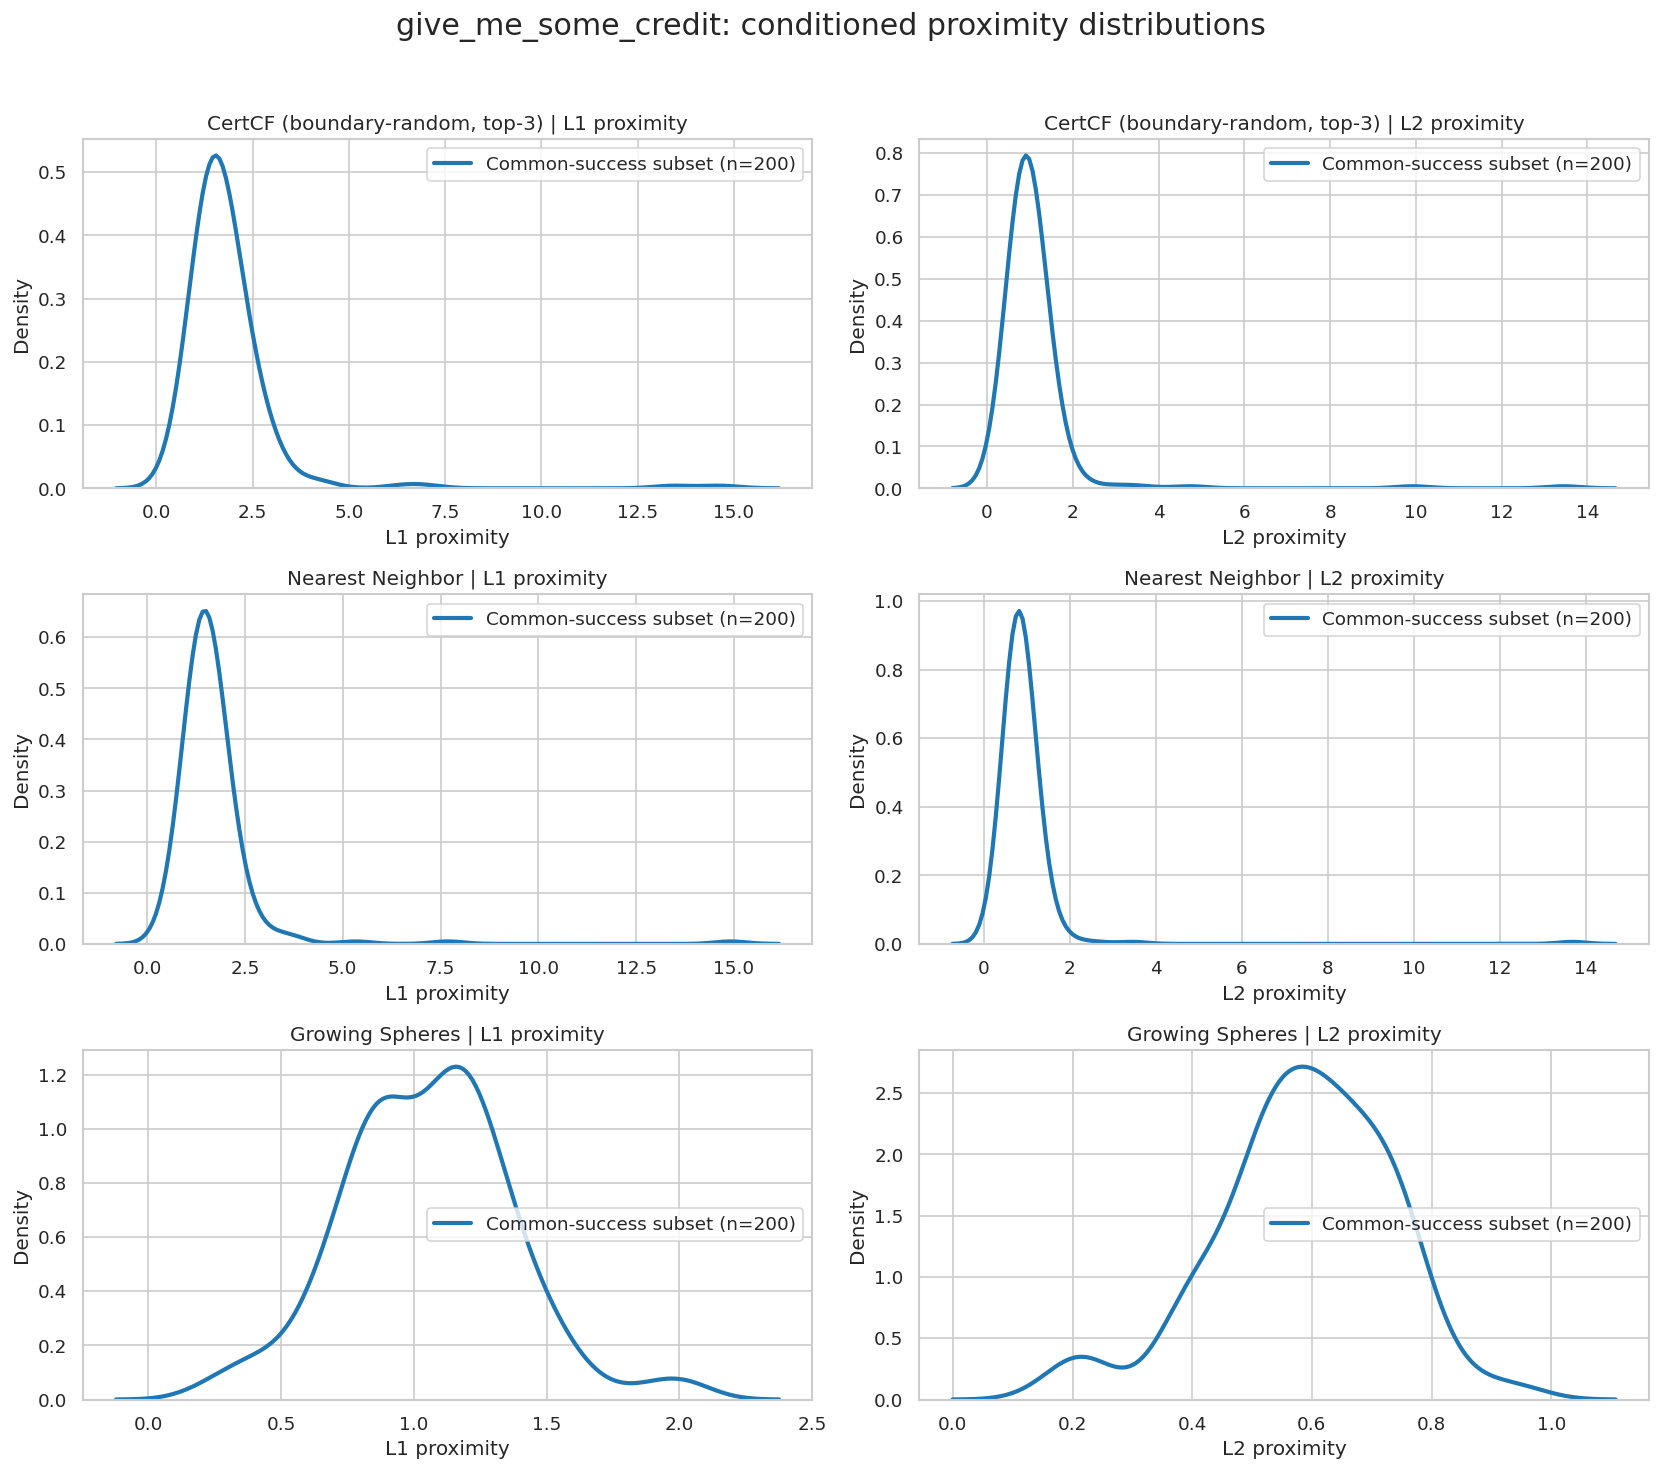

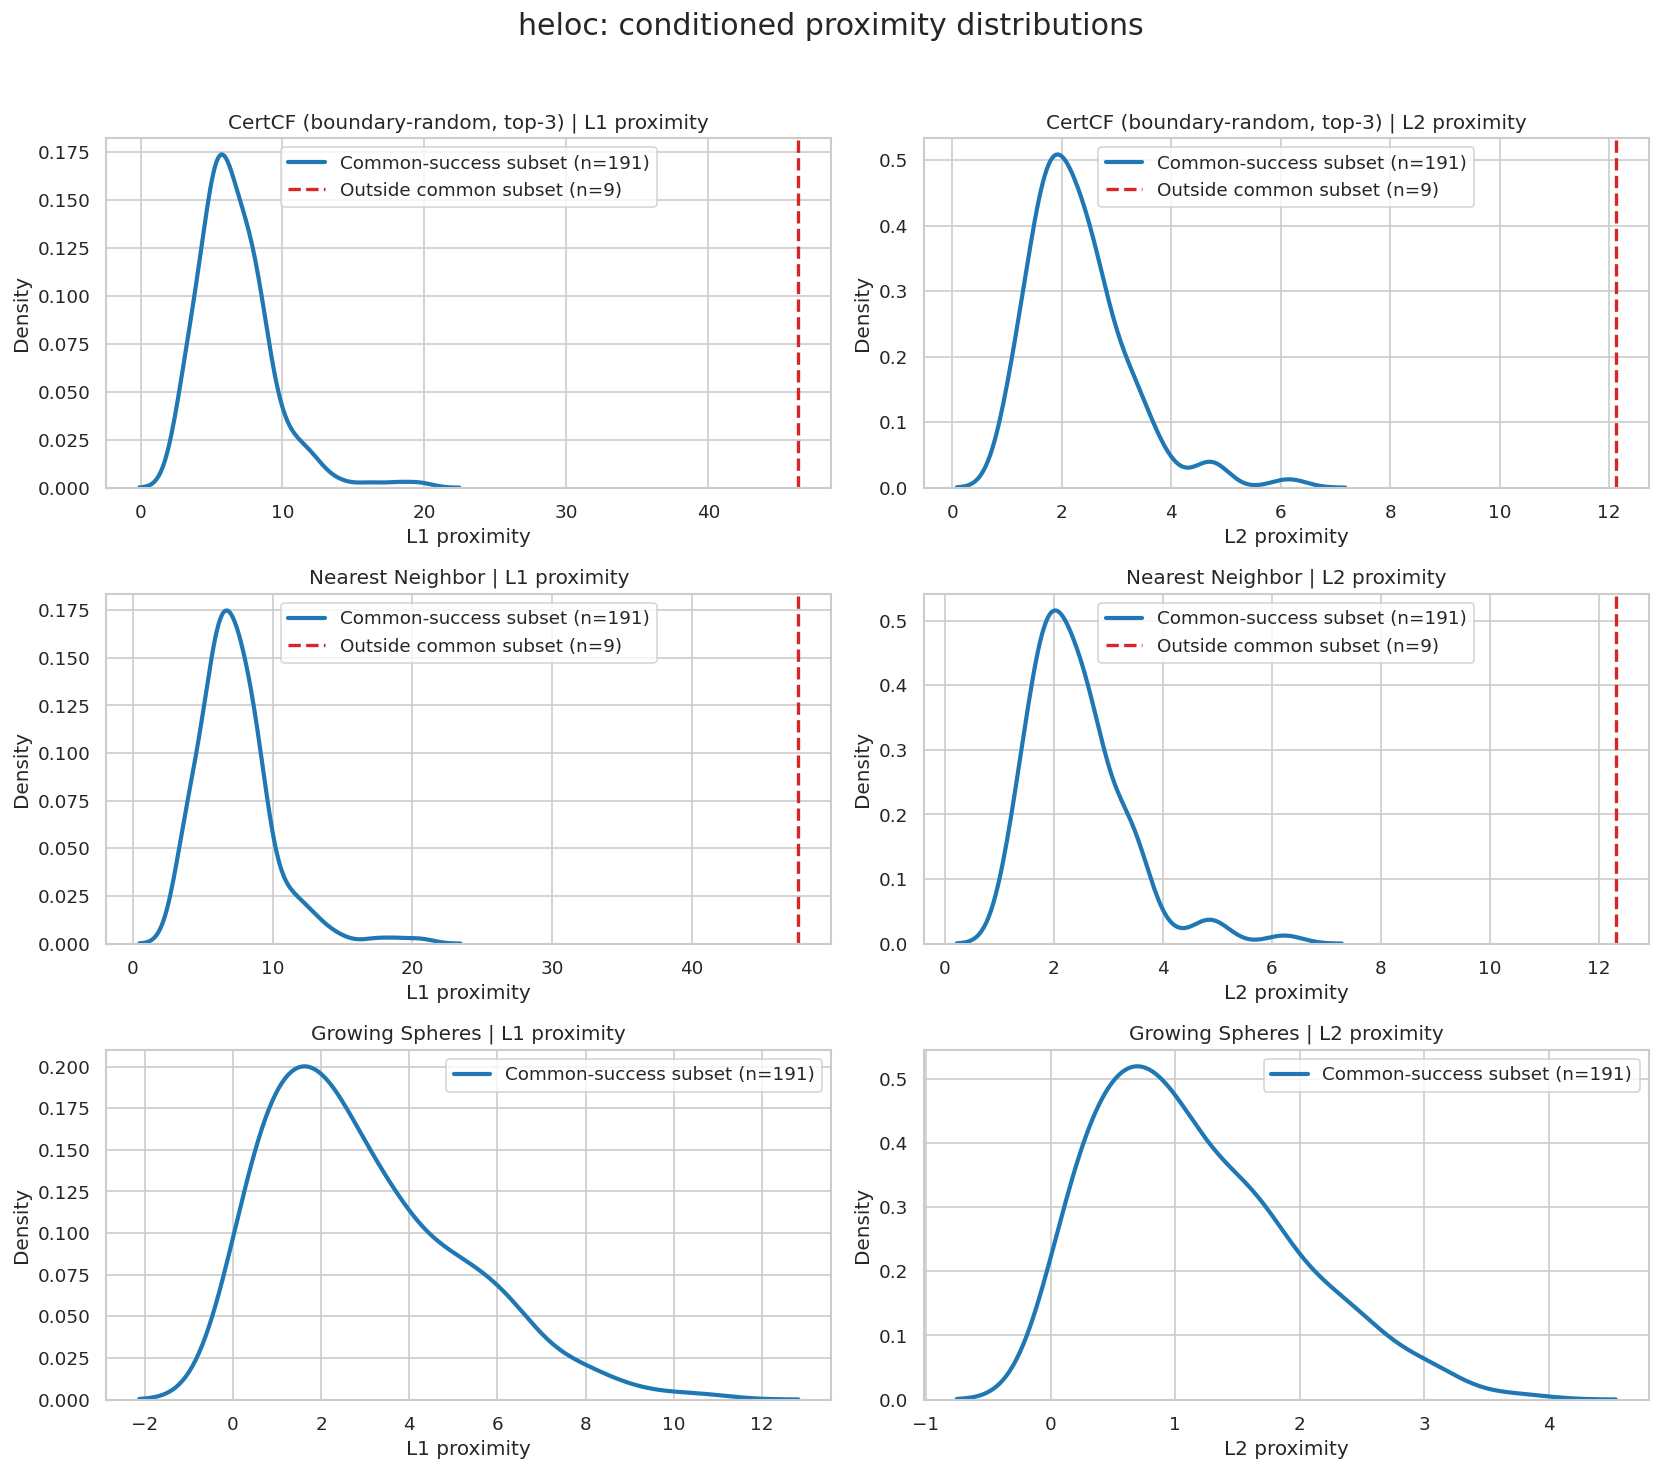

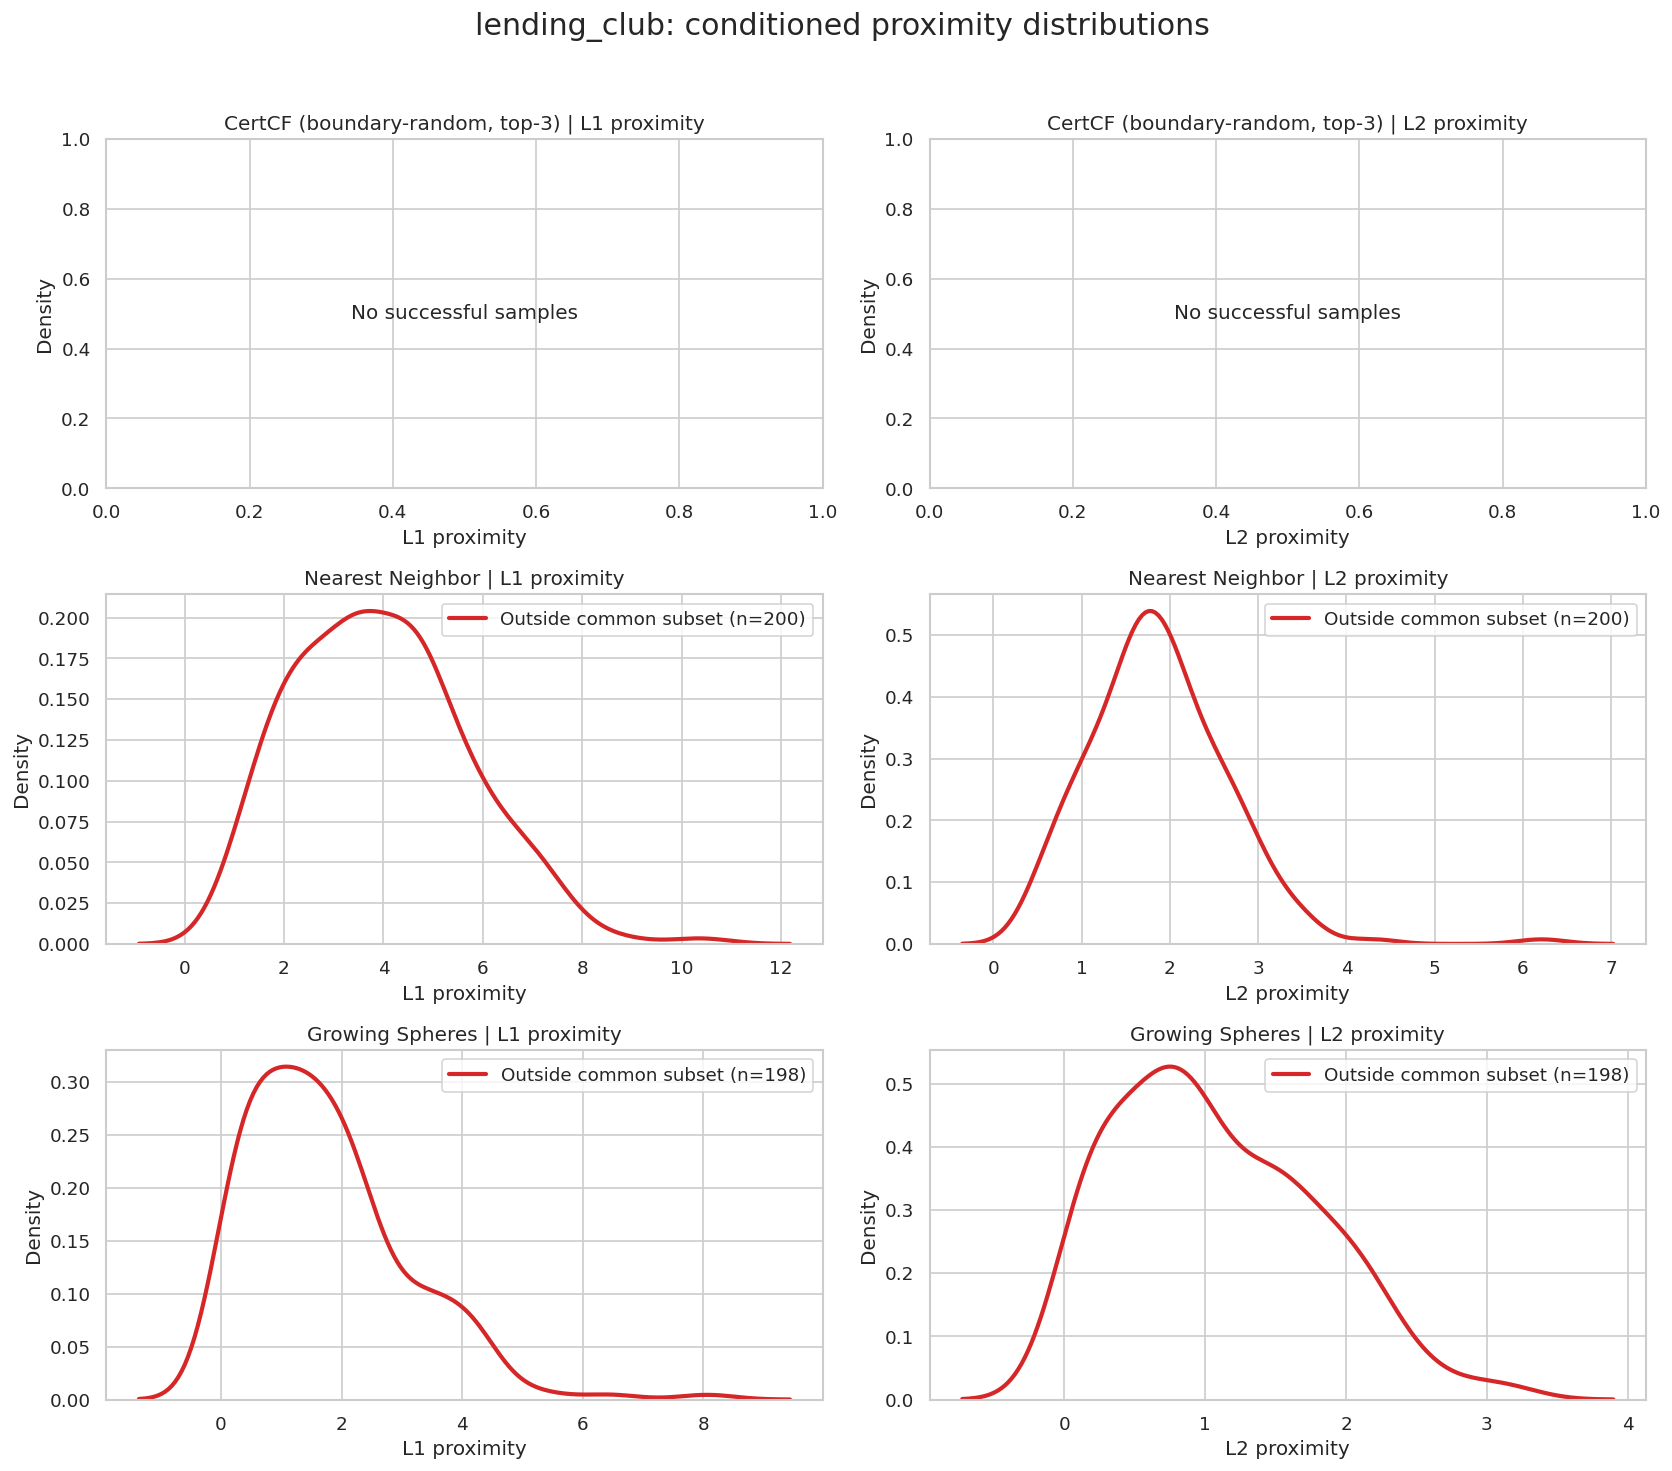

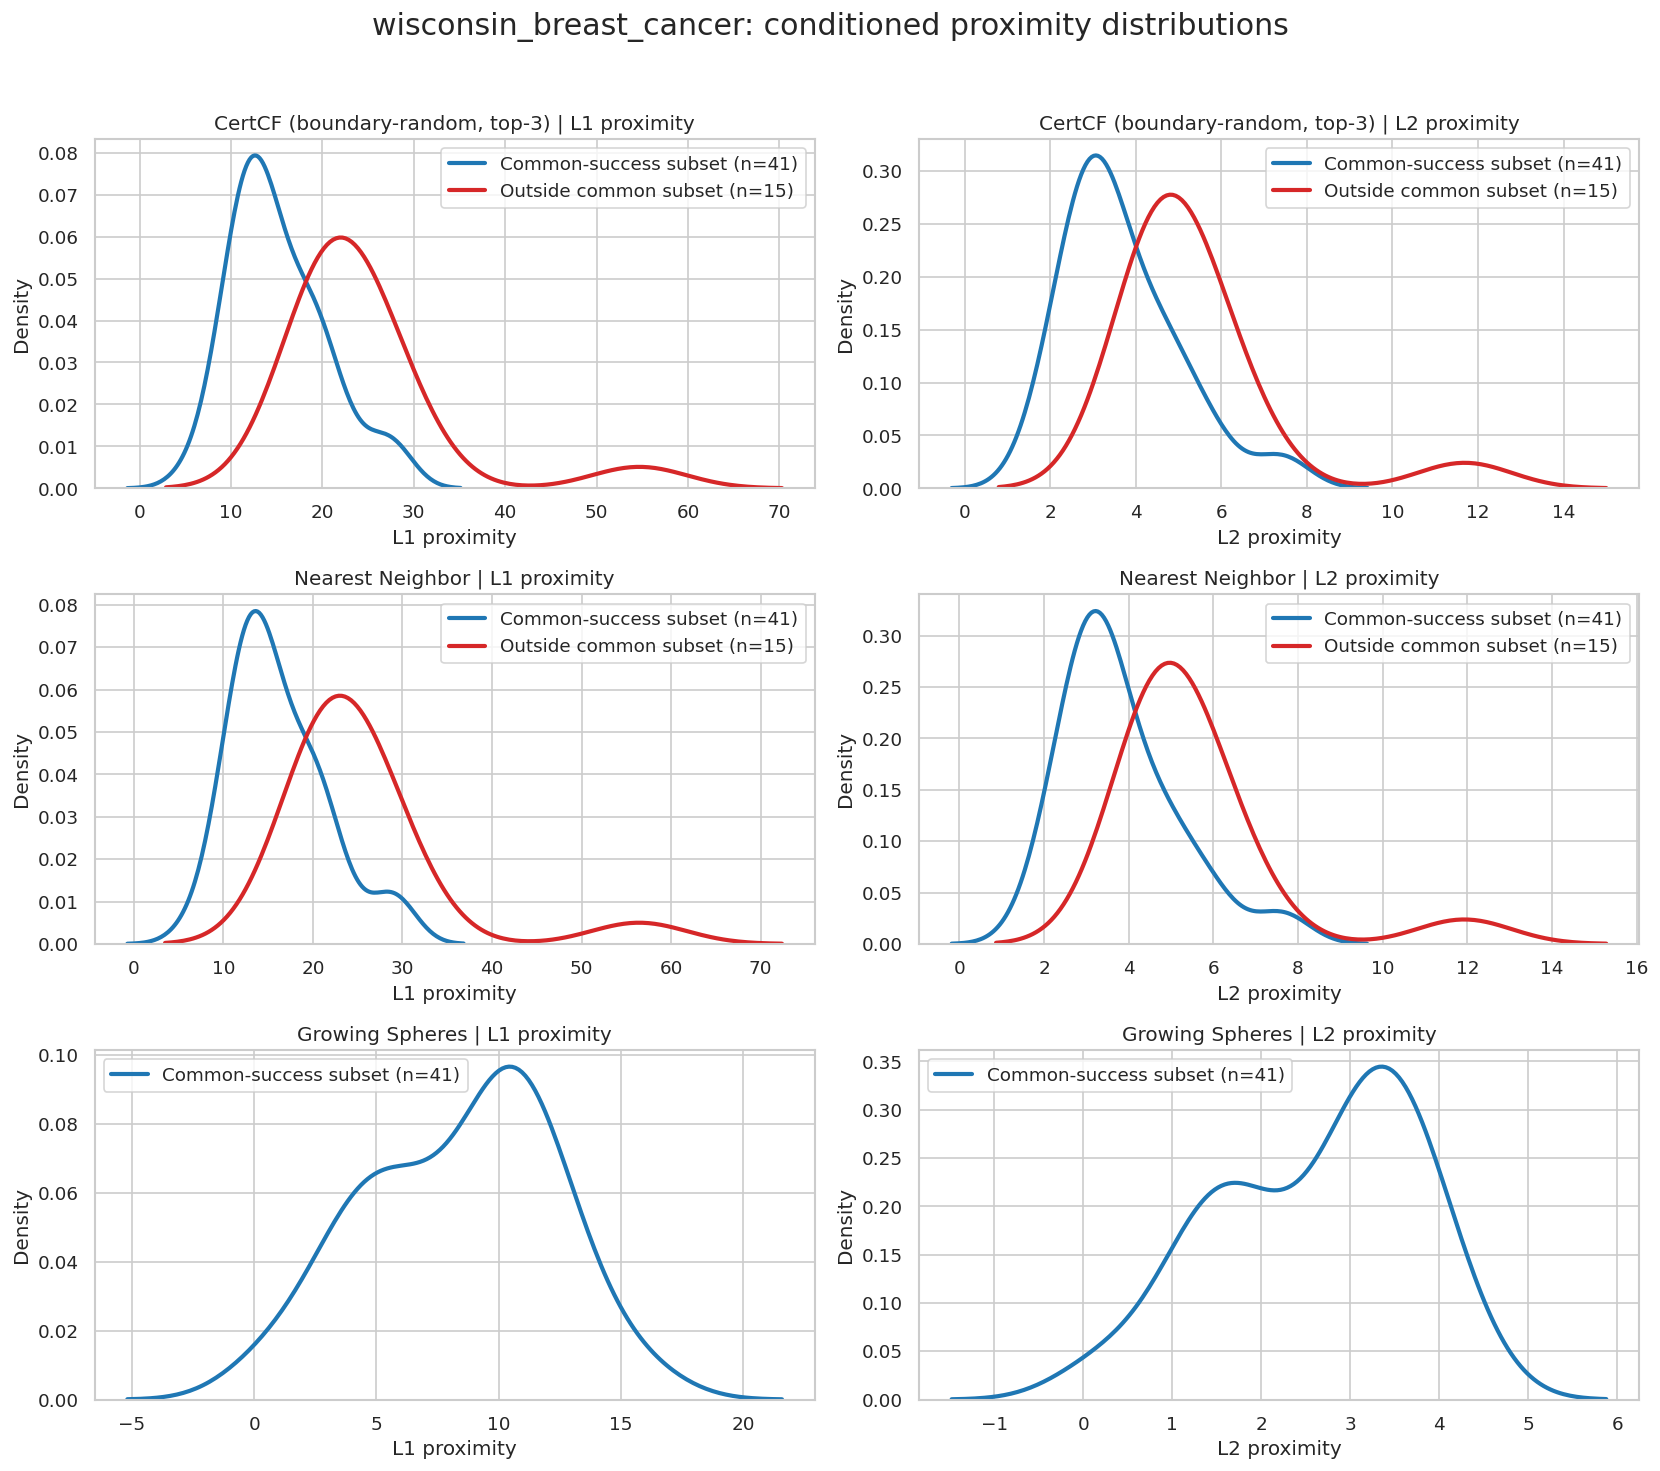

In [6]:
subset_kde_df = annotate_common_success_subset(
    plot_df,
    by=("dataset", "query_idx"),
    method_col="method_label",
)

SUBSET_ORDER = ["Common-success subset", "Outside common subset"]
SUBSET_PALETTE = {
    "Common-success subset": "#1f77b4",
    "Outside common subset": "#d62728",
}

figures = plot_conditioned_proximity_kdes(
    subset_kde_df,
    dataset_order=DATASET_ORDER,
    method_order=METHOD_ORDER,
    subset_col="subset_group",
    subset_order=SUBSET_ORDER,
    subset_palette=SUBSET_PALETTE,
    method_titles=METHOD_LABELS,
)
for _, fig, _ in figures:
    plt.show()


## Manifoldness Metrics

We start with three plausibility proxies computed on successful counterfactuals only:

1. `kNN-5 (all train)` — mean distance to the 5 nearest training points.
2. `kNN-5 (predicted target class)` — mean distance to the 5 nearest training points whose **predicted** class matches the counterfactual class.
3. `-LOF (all train)` — the negative of the Local Outlier Factor novelty score on the training set.

How to read them:

- Lower is better for `kNN-5 (all train)`: the counterfactual lies closer to the empirical data manifold.
- Lower is better for `kNN-5 (predicted target class)`: the counterfactual looks more like a realistic member of the class it flips into.
- Lower is better for `-LOF (all train)`: smaller values correspond to less outlier-like points, while larger values indicate stronger outlier behavior.

In practice, the second metric is often the most informative one for counterfactual realism, because it checks whether the CF lands near plausible examples of its **target** class rather than just near any training point.

In [7]:
resources_by_dataset = load_tabular_manifold_resources(
    CONFIG_PATH,
    datasets=DATASET_ORDER,
    device="cpu",
)
manifold_df = attach_tabular_manifoldness_metrics(
    plot_df,
    resources_by_dataset=resources_by_dataset,
)
manifold_summary = summarize_manifoldness(
    manifold_df,
    order=METHOD_ORDER,
)
display(manifold_summary.round(3))


[INFO] Retrying checkpoint load with hidden_dims inferred from checkpoint: [128, 32]


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/utils/manifoldness.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for dataset_name, dataset_df in data.groupby(dataset_col, sort=False):
/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/utils/summaries.py:489: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby([dataset_col, method_col], dropna=False).agg(**agg_spec).reset_index()


,dataset,method_label,n,knn5_all_mean,knn5_all_median,knn5_target_mean,knn5_target_median,neg_lof_all_mean,neg_lof_all_median
0,adult,certcf_top3,200,1.048,0.992,1.178,1.138,1.260000e+00,1.171
1,adult,nn,200,0.948,0.950,1.149,1.212,1.276000e+00,1.176
2,adult,gs,163,1.444,1.506,1.971,2.112,1.368000e+00,1.287
3,compas,certcf_top3,200,0.219,0.176,0.293,0.206,3.814671e+06,1.089
4,compas,nn,200,0.174,0.150,0.234,0.160,6.388801e+05,1.074
5,compas,gs,200,0.409,0.299,0.540,0.455,2.130909e+05,1.251
6,german_credit,certcf_top3,100,2.388,2.402,2.517,2.505,1.024000e+00,1.017
7,german_credit,nn,100,2.285,2.261,2.448,2.408,1.024000e+00,1.022
8,german_credit,gs,62,3.169,3.095,3.410,3.361,1.056000e+00,1.041
9,give_me_some_credit,certcf_top3,200,0.483,0.429,0.560,0.495,1.619000e+00,1.464


## Notes

- KDE curves are computed on successful counterfactuals only.
- To compare failure behavior, use the summary table (`valid_pct`) above.
- The matched-success table is stricter: it compares methods only on query points solved by all of them.
- The conditioned KDE plots show how each method's successful-query distribution changes inside versus outside that common subset.